In [6]:
"""Titanic - Machine Learning from Disaster
Start here! Predict survival on the Titanic and get familiar with ML basics"""
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# Load the dataset
data = pd.read_csv('train.csv')

# Display the first few rows of the dataset to understand its structure
print(data.head())
# Check for missing values
print(data.isnull().sum())
# Basic statistics of the dataset
print(data.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

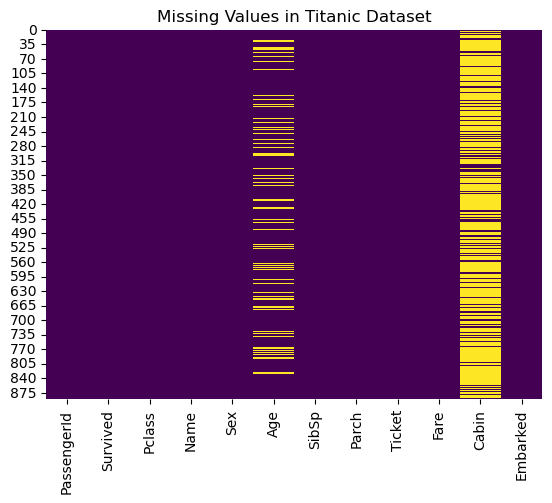

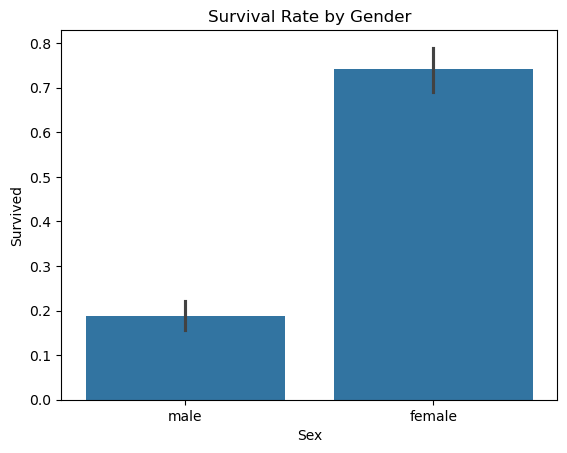

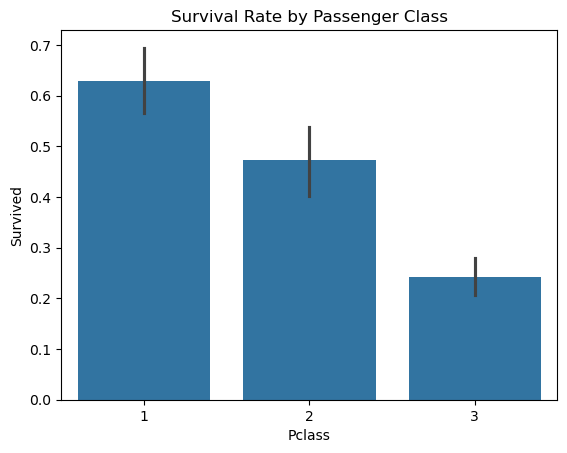

In [7]:
# Visualize the data to understand relationships and missing values
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Titanic Dataset')
plt.show()

# Survival by gender
sns.barplot(x='Sex', y='Survived', data=data)
plt.title('Survival Rate by Gender')
plt.show()

# Survival by class
sns.barplot(x='Pclass', y='Survived', data=data)
plt.title('Survival Rate by Passenger Class')
plt.show()

In [8]:
# Clearing the data
# Fill missing Age values with the median age
data['Age'].fillna(data['Age'].median(), inplace=True)
# Fill missing Embarked values with the most common port
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
# Drop the Cabin column due to too many missing values
data.drop('Cabin', axis=1, inplace=True)
# Drop rows with any remaining missing values
data.dropna(inplace=True)

data.head(5)

C:\Users\Aryan\AppData\Local\Temp\ipykernel_12648\578769203.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
C:\Users\Aryan\AppData\Local\Temp\ipykernel_12648\578769203.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [9]:
# Feature engineering
# Convert categorical variables into dummy/indicator variables
data = pd.get_dummies(data, columns=['Sex', 'Embarked'], drop_first=True)
data.drop(['Name', 'Ticket'], axis=1, inplace=True)


In [10]:
# Modeling
# Define features and target variable
X = data.drop('Survived', axis=1)
y = data['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
# Train the model
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [12]:
from sklearn.metrics import accuracy_score
# Evaluate the model
predictions = model.predict(X_test)
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print("Accuracy:", accuracy_score(y_test, predictions))

# Save the model for future use
import joblib
joblib.dump(model, 'titanic_survival_model.pkl')


[[92 13]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

Accuracy: 0.8212290502793296


['titanic_survival_model.pkl']

In [15]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np

# 1. Load the model ONCE at the top (better performance)
# Make sure the .pkl file is in the same folder
model = joblib.load('titanic_survival_model.pkl')

st.title("🚢 Titanic Survival Prediction")
st.write("Enter the details of the passenger to predict survival.")

# --- INPUT FIELDS ---

# Passenger Class
pclass = st.selectbox('Passenger Class', [1, 2, 3], format_func=lambda x: f"{x}st/nd/rd Class")

# Gender (UX improvement: Text instead of 0/1)
sex = st.selectbox('Sex', ["Male", "Female"])

# Age
age = st.slider('Age', 0, 100, 30)

# Family details
sibsp = st.number_input('Siblings/Spouses Aboard', 0, 10, 0)
parch = st.number_input('Parents/Children Aboard', 0, 10, 0)

# Fare
fare = st.number_input('Fare Price (£)', 0.0, 512.0, 32.0)

# Embarkation Port (UX improvement: Dropdown instead of multiple checkboxes)
embarked = st.selectbox('Port of Embarkation', ["Southampton (S)", "Cherbourg (C)", "Queenstown (Q)"])

# --- PRE-PROCESSING (Mirroring the Training Step) ---

if st.button('Predict Survival'):
    # 1. Calculate Derived Features
    family_size = sibsp + parch + 1
    is_alone = 1 if family_size == 1 else 0

    # 2. Encode Categorical Variables
    # Sex: Female=1, Male=0 (Matches our training map)
    sex_encoded = 1 if sex == "Female" else 0
    
    # Embarked: One-Hot Encoding logic
    # We need Embarked_Q and Embarked_S columns
    embarked_q = 1 if "Queenstown" in embarked else 0
    embarked_s = 1 if "Southampton" in embarked else 0
    # Note: If Cherbourg is selected, both Q and S are 0, which is correct for One-Hot Encoding

    # 3. Create DataFrame with EXACT column names and order as training
    input_data = pd.DataFrame({
        'Pclass': [pclass],
        'Sex': [sex_encoded],     # Note: Check if your training put Sex before Age or after
        'Age': [age],
        'SibSp': [sibsp],
        'Parch': [parch],
        'Fare': [fare],
        'FamilySize': [family_size],
        'IsAlone': [is_alone],
        'Embarked_Q': [embarked_q],
        'Embarked_S': [embarked_s]
    })

    # 4. Predict
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    # 5. Display Result
    if prediction == 1:
        st.success(f"Prediction: Survived! 🟢 (Confidence: {probability:.2%})")
        st.balloons()
    else:
        st.error(f"Prediction: Did Not Survive 🔴 (Confidence: {1-probability:.2%})")

2025-12-17 00:07:35.976 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-17 00:07:36.049 
  command:

    streamlit run c:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-12-17 00:07:36.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-17 00:07:36.051 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-17 00:07:36.052 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-17 00:07:36.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-17 00:07:36.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-17 00:07:36.055 Thread 'MainThread': mi